Loaded X_finesat with shape: (50, 78)
Loaded Y_finesat with shape: (50,)

Training FineSat SVM...

🏆 FineSat Pipeline Accuracy: 80.00%

Classification Report:
              precision    recall  f1-score   support

           m       1.00      1.00      1.00         2
        push       0.50      0.50      0.50         2
    pushpull       0.67      1.00      0.80         2
        star       1.00      1.00      1.00         2
    triangle       1.00      0.50      0.67         2

    accuracy                           0.80        10
   macro avg       0.83      0.80      0.79        10
weighted avg       0.83      0.80      0.79        10



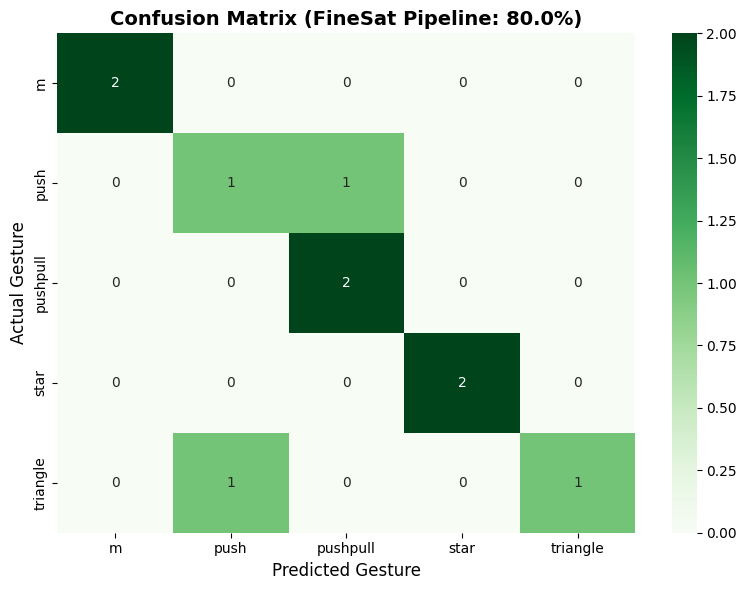

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the FineSat feature matrix and labels
X_fs = np.load("X_finesat.npy")
Y_fs = np.load("Y_finesat.npy")

print(f"Loaded X_finesat with shape: {X_fs.shape}")
print(f"Loaded Y_finesat with shape: {Y_fs.shape}")

# 2. Encode labels ('m', 'push', 'star', etc.) into numbers
label_encoder_fs = LabelEncoder()
Y_encoded_fs = label_encoder_fs.fit_transform(Y_fs)

# 3. Train/Test Split (80% training, 20% testing)
X_train_fs, X_test_fs, Y_train_fs, Y_test_fs = train_test_split(
    X_fs, Y_encoded_fs, test_size=0.2, random_state=42, stratify=Y_encoded_fs
)

# 4. Scale features (Mean=0, Variance=1)
scaler_fs = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_fs)
X_test_scaled_fs = scaler_fs.transform(X_test_fs)

# 5. Train the SVM
print("\nTraining FineSat SVM...")
svm_model_fs = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model_fs.fit(X_train_scaled_fs, Y_train_fs)

# 6. Predict & Evaluate
Y_pred_fs = svm_model_fs.predict(X_test_scaled_fs)
accuracy_fs = accuracy_score(Y_test_fs, Y_pred_fs)

print(f"\n🏆 FineSat Pipeline Accuracy: {accuracy_fs * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(Y_test_fs, Y_pred_fs, target_names=label_encoder_fs.classes_))

# 7. Plot Confusion Matrix
cm_fs = confusion_matrix(Y_test_fs, Y_pred_fs)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder_fs.classes_, 
            yticklabels=label_encoder_fs.classes_)
plt.title(f"Confusion Matrix (FineSat Pipeline: {accuracy_fs * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()